In [1]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# make regression class helps to create a regression dataset
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=42)

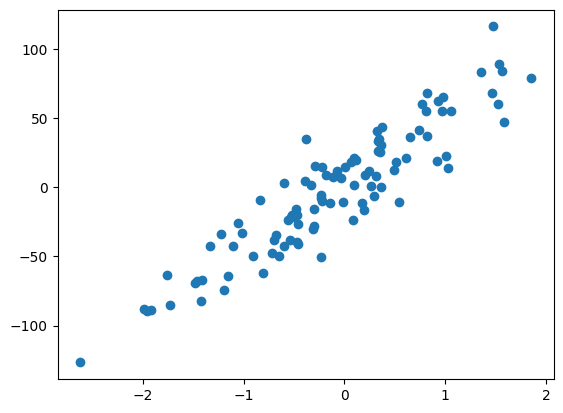

In [3]:
plt.scatter(X, y)

# Check the coeff and intercept using Linear regression 

In [4]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [5]:
# Get the coefficients and the intercept from the sklearn class
lr.coef_, lr.intercept_

(array([47.13323967]), 2.3302306410539453)

In [6]:
from sklearn.metrics import r2_score
r2_score(y, lr.predict(X))

0.853154207317982

In [7]:
# class to define the Gradient Descent Regressor 
class GDRegressor:
    def __init__(self, n_iterations, learning_rate=0.01):
        # pre defined learning rate and number of iterations
        # random initial values for m and b
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.m = 44.43
        self.b = -10

    def fit(self, X, y):
        for i in range(self.n_iterations):
            # when we differentiate the loss function wrt b we get the intercept 
            # when we differentiate the loss function wrt m we get the slope
            loss_slope_b = -2 * np.sum(y - self.m* X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m * X.ravel() - self.b)*X.ravel())# ravel function is used to convert the 2D array into 1D array
            # formulae of gradient descent
            self.b = self.b - self.learning_rate * loss_slope_b
            self.m = self.m - self.learning_rate * loss_slope_m

        print(self.b, self.m)
    # formulae of gradient descent predictions
    def predict(self, X):
        return self.m * X.ravel() + self.b

In [17]:
gd = GDRegressor(n_iterations=100, learning_rate=0.01)
gd.fit(X, y)

-98769.64587801206 46375.207162751096


In [9]:
lr.coef_, lr.intercept_

(array([47.13323967]), 2.3302306410539453)

# The coef and intercept of the sklearn and self made class are almost equal to each other

In [10]:
gd = GDRegressor(n_iterations=1000, learning_rate=0.001)
gd.fit(X, y)


2.3302306410539426 47.13323966963204


In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
gd = GDRegressor(n_iterations=1000, learning_rate=0.001)
gd.fit(X_train, y_train)    

0.1984444284517554 46.74726399707049


In [12]:
r2_score(y_test, gd.predict(X_test))

0.8019015156159199